(endogenous_lake)=
```{raw} jupyter
<div id="qe-notebook-header" align="right" style="text-align:right;">
        <a href="https://quantecon.org/" title="quantecon.org">
                <img style="width:250px;display:inline;" width="250px" src="https://assets.quantecon.org/img/qe-menubar-logo.svg" alt="QuantEcon">
        </a>
</div>
```

# 具有内生工作发现率的湖泊模型

```{include} _admonition/gpu.md
```

```{index} single: Lake Model, Endogenous
```

```{contents} Contents
:depth: 2
```

除了 Anaconda 中已有的内容外，本讲座还需要以下库：

In [1]:
!pip install quantecon jax

## 概述

本讲座是 {doc}`湖泊模型讲座 <lake_model>` 的续篇。

我们建议你在继续本讲座之前先阅读那篇讲座。

在上一讲座中，我们研究了一个关于失业和就业的湖泊模型，其中状态之间的转移率是外生参数。

在本讲座中，我们通过使工作发现率变为内生的来扩展该模型。

具体来说，从失业到就业的转移率将由 McCall 搜寻模型 {cite}`McCall1970` 决定。

让我们从一些导入开始：

In [2]:
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from typing import NamedTuple
from quantecon.distributions import BetaBinomial
from functools import partial
import jax.scipy.stats as stats
import matplotlib as mpl  # i18n
FONTPATH = "fonts/SourceHanSerifSC-SemiBold.otf"  # i18n
mpl.font_manager.fontManager.addfont(FONTPATH)  # i18n
mpl.rcParams['font.family'] = ['Source Han Serif SC']  # i18n

## 设置

模型的基本结构将如 {doc}`湖泊模型讲座 <lake_model>` 中所讨论的那样。

唯一的区别是雇佣率是内生的，由居住在 McCall 搜寻模型 {cite}`McCall1970` 中的最优化代理人的决策决定，其中工资报价为独立同分布，工作分离率为 $\alpha$。


### 保留工资

在模型中，最优策略由一个保留工资 $\bar w$ 刻画

* 如果手中的工资报价 $w$ 大于或等于 $\bar w$，则工人接受。
* 否则，工人拒绝。

保留工资取决于工资报价分布和以下参数

* $\alpha$，分离率
* $\beta$，贴现因子
* $\gamma$，报价到达率
* $c$，失业补偿

工资报价分布将是对数正态分布的离散化版本。

我们首先定义一个函数来创建这样的离散分布。

In [3]:
def create_wage_distribution(
        max_wage: float,
        wage_grid_size: int,
        log_wage_mean: float
    ):
    """
    创建对数正态密度 LN(log(m),1) 的离散化版本，其中
    m 是 log_wage_mean。

    """
    w_vec_temp = jnp.linspace(1e-8, max_wage, wage_grid_size + 1)
    cdf = stats.norm.cdf(
        jnp.log(w_vec_temp), loc=jnp.log(log_wage_mean), scale=1
    )
    pdf = cdf[1:] - cdf[:-1]
    p_vec = pdf / pdf.sum()
    w_vec = (w_vec_temp[1:] + w_vec_temp[:-1]) / 2
    return w_vec, p_vec

下面的单元格创建一个离散化的 $LN(\log(20),1)$ 工资分布并将其绘制出来。

findfont: Failed to find font weight normal, now using 600.


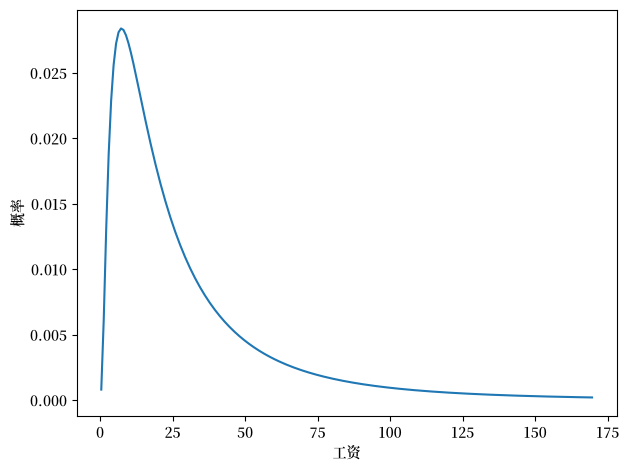

In [4]:
w_vec, p_vec = create_wage_distribution(170, 200, 20)

fig, ax = plt.subplots()
ax.plot(w_vec, p_vec)
ax.set_xlabel('工资')
ax.set_ylabel('概率')
plt.tight_layout()
plt.show()

现在我们组织给定一组参数下求解 McCall 模型的代码。

关于该模型及我们求解方法的背景，请参阅 {doc}`关于具有分离的 McCall 模型的讲座 <mccall_model_with_separation>`

我们的第一步是定义效用函数和 McCall 模型数据结构。

In [5]:
def u(c, σ=2.0):
    return jnp.where(c > 0, (c**(1 - σ) - 1) / (1 - σ), -10e6)


class McCallModel(NamedTuple):
    """
    存储 McCall 搜寻模型的参数
    """
    α: float            # 工作分离率
    β: float            # 贴现率
    γ: float            # 工作报价率
    c: float            # 失业补偿
    σ: float            # 效用参数
    w_vec: jnp.ndarray  # 可能的工资值
    p_vec: jnp.ndarray  # w_vec 上的概率


def create_mccall_model(
        α=0.2, β=0.98, γ=0.7, c=6.0, σ=2.0,
        w_vec=None, 
        p_vec=None
    ) -> McCallModel:
    if w_vec is None:
        n = 60  # 工资可能结果的数量
        # 工资在 10 到 20 之间
        w_vec = jnp.linspace(10, 20, n)
        a, b = 600, 400  # 形状参数
        dist = BetaBinomial(n-1, a, b)
        p_vec = jnp.array(dist.pdf())
    return McCallModel(
        α=α, β=β, γ=γ, c=c, σ=σ, w_vec=w_vec, p_vec=p_vec
    )

接下来，我们实现贝尔曼算子

In [6]:
def T(mcm: McCallModel, V, U):
    """
    更新贝尔曼方程。
    """
    α, β, γ, c, σ = mcm.α, mcm.β, mcm.γ, mcm.c, mcm.σ
    w_vec, p_vec = mcm.w_vec, mcm.p_vec

    V_new = u(w_vec, σ) + β * ((1 - α) * V + α * U)
    U_new = u(c, σ) + β * (1 - γ) * U + β * γ * (jnp.maximum(U, V) @ p_vec)

    return V_new, U_new

现在我们定义值函数迭代求解器。

我们将使用编译的 while 循环以获得额外的速度。

In [7]:
@jax.jit
def solve_mccall_model(mcm: McCallModel, tol=1e-5, max_iter=2000):
    """
    对贝尔曼方程迭代直到收敛。
    """
    def cond(state):
        V, U, i, error = state
        return jnp.logical_and(error > tol, i < max_iter)

    def update(state):
        V, U, i, error = state
        V_new, U_new = T(mcm, V, U)
        error_1 = jnp.max(jnp.abs(V_new - V))
        error_2 = jnp.abs(U_new - U)
        error_new = jnp.maximum(error_1, error_2)
        return V_new, U_new, i + 1, error_new

    # 初始状态
    V_init = jnp.ones(len(mcm.w_vec))
    U_init = 1.0
    i_init = 0
    error_init = tol + 1

    init_state = (V_init, U_init, i_init, error_init)
    V_final, U_final, _, _ = jax.lax.while_loop(
        cond, update, init_state
    )
    return V_final, U_final

### 湖泊模型代码

我们还需要上一讲座中的湖泊模型函数来计算稳态失业率：

In [8]:
class LakeModel(NamedTuple):
    """
    湖泊模型的参数
    """
    λ: float
    α: float
    b: float
    d: float
    A: jnp.ndarray
    R: jnp.ndarray
    g: float


def create_lake_model(
        λ: float = 0.283,     # 工作发现率
        α: float = 0.013,     # 分离率
        b: float = 0.0124,    # 出生率
        d: float = 0.00822    # 死亡率
    ) -> LakeModel:
    """
    使用默认参数创建 LakeModel 实例。

    计算并存储转移矩阵 A 和 R，
    以及劳动力增长率 g。

    """
    # 计算增长率
    g = b - d

    # 计算转移矩阵 A
    A = jnp.array([
        [(1-d) * (1-λ) + b, (1-d) * α + b],
        [(1-d) * λ,         (1-d) * (1-α)]
    ])

    # 计算归一化的转移矩阵 R
    R = A / (1 + g)

    return LakeModel(λ=λ, α=α, b=b, d=d, A=A, R=R, g=g)


@jax.jit
def rate_steady_state(model: LakeModel) -> jnp.ndarray:
    r"""
    通过计算对应于最大特征值的特征向量，
    找到系统 :math:`x_{t+1} = R x_{t}` 的稳态。

    根据佩龙-弗罗贝尼乌斯定理，由于 :math:`R` 是一个各列
    之和为 1 的非负矩阵（随机矩阵），最大特征值等于 1，
    对应的特征向量给出稳态。
    """
    λ, α, b, d, A, R, g = model
    eigenvals, eigenvec = jnp.linalg.eig(R)

    # 找到对应于最大特征值的特征向量
    # （对于随机矩阵，根据佩龙-弗罗贝尼乌斯定理该值为 1）
    max_idx = jnp.argmax(jnp.abs(eigenvals))

    # 获取对应的特征向量
    steady_state = jnp.real(eigenvec[:, max_idx])

    # 归一化以确保正值且和为 1
    steady_state = jnp.abs(steady_state)
    steady_state = steady_state / jnp.sum(steady_state)

    return steady_state

### 将 McCall 搜寻模型与湖泊模型联系起来

假设湖泊模型内的所有工人都按照 McCall 搜寻模型行事。

离开就业的外生概率仍然是 $\alpha$。

但他们的最优决策规则决定了离开失业的概率 $\lambda$。

现在这是

```{math}
:label: endogenous_lake_lambda

\lambda
= \gamma \mathbb P \{ w_t \geq \bar w\}
= \gamma \sum_{w' \geq \bar w} p(w')
```

其中

* $\bar w$ 是由参数决定的保留工资，
* $p$ 是工资报价分布。

工人群体中的工资报价是从 $p$ 中独立抽取的。

这里我们在默认参数下计算 $\lambda$：

In [9]:
mcm = create_mccall_model(w_vec=w_vec, p_vec=p_vec)
V, U = solve_mccall_model(mcm)
w_idx = jnp.searchsorted(V - U, 0)
w_bar = jnp.where(w_idx == len(V), jnp.inf, mcm.w_vec[w_idx])
λ = mcm.γ * jnp.sum(p_vec * (w_vec > w_bar))
print(f"默认参数下的工作发现率 ={λ}.")

默认参数下的工作发现率 =0.4510621428489685.


## 财政政策

在本节中，我们将运用湖泊模型，考察与不同水平的失业补偿相关联的结果。

我们的目标是找到失业保险的最优水平。

我们假设政府设定失业补偿 $c$。

政府征收足以为总失业支付提供资金的一次性总付税 $\tau$。

要在稳态下实现预算平衡，税收、稳态失业率 $u$ 和失业补偿率必须满足

$$
    \tau = u c
$$

一次性总付税适用于每个人，包括失业工人。

* 工资为 $w$ 的就业工人的税后收入为 $w - \tau$。
* 失业工人的税后收入为 $c - \tau$。

对于政府政策的每一种设定 $(c, \tau)$，我们都可以求解工人的最优保留工资。

这通过在税后工资上求值的 {eq}`endogenous_lake_lambda` 确定 $\lambda$，进而又确定一个稳态失业率 $u(c, \tau)$。

对于给定水平的失业补助 $c$，我们可以求解一个在稳态下平衡预算的税收

$$
    \tau = u(c, \tau) c
$$

要评估各种备选的政府税收-失业补偿组合，我们需要一个福利标准。

我们使用稳态福利标准

$$
    W := e \,  {\mathbb E} [V \, | \,  \text{employed}] + u \,  U
$$

其中记号 $V$ 和 $U$ 如上文所定义，期望是在稳态下取的。




### 计算最优失业保险

现在我们建立计算最优失业保险水平的基础设施。

首先，我们为经济体的参数定义一个容器：

In [10]:
class Economy(NamedTuple):
    """经济体的参数"""
    α: float
    b: float
    d: float
    β: float
    γ: float
    σ: float
    log_wage_mean: float
    wage_grid_size: int
    max_wage: float

def create_economy(
        α=0.013, 
        b=0.0124, 
        d=0.00822,
        β=0.98, 
        γ=1.0, 
        σ=2.0,
        log_wage_mean=20,
        wage_grid_size=200,
        max_wage=170
    ) -> Economy:
    """
    使用一组默认值创建一个经济体"""
    return Economy(α=α, b=b, d=d, β=β, γ=γ, σ=σ,
                           log_wage_mean=log_wage_mean,
                           wage_grid_size=wage_grid_size,
                           max_wage=max_wage)

接下来，我们定义一个函数，在给定政策参数下计算工人的最优行为：

In [11]:
@jax.jit
def compute_optimal_quantities(
        c: float, 
        τ: float, 
        economy: Economy, 
        w_vec: jnp.array, 
        p_vec: jnp.array
    ):
    """
    在给定 c 和 τ 的情况下，计算工人的保留工资、
    工作发现率和值函数。

    """
    mcm = create_mccall_model(
        α=economy.α,
        β=economy.β,
        γ=economy.γ,
        c=c-τ,          # 税后补偿
        σ=economy.σ,
        w_vec=w_vec-τ,  # 税后工资
        p_vec=p_vec
    )

    # 在给定参数下计算保留工资
    V, U = solve_mccall_model(mcm)
    w_idx = jnp.searchsorted(V - U, 0)
    w_bar = jnp.where(w_idx == len(V), jnp.inf, mcm.w_vec[w_idx])

    # 计算工作发现率
    λ = economy.γ * jnp.sum(p_vec * (w_vec - τ > w_bar))

    return w_bar, λ, V, U

此函数在给定失业保险和税收水平的情况下计算稳态结果：

In [12]:
@jax.jit
def compute_steady_state_quantities(
        c, τ, economy: Economy, w_vec, p_vec
    ):
    """
    在给定 c 和 τ 的情况下，使用来自 McCall 模型的最优量并
    计算相应的稳态量，从而计算稳态失业率

    """

    # 通过求解 McCall 模型找到最优值和策略，
    # 以及相应的工作发现率。
    w_bar, λ, V, U = compute_optimal_quantities(c, τ, economy, w_vec, p_vec)

    # 使用给定参数和工作发现率建立一个湖泊模型。
    model = create_lake_model(λ=λ, α=economy.α, b=economy.b, d=economy.d)

    # 从该湖泊模型计算稳态就业率和失业率。
    u, e = rate_steady_state(model)

    # 计算以就业为条件的预期终身价值。
    mask = (w_vec - τ > w_bar)
    w = jnp.sum(V * p_vec * mask) / jnp.sum(p_vec * mask)
    # 计算稳态福利。
    welfare = e * w + u * U

    return e, u, welfare

我们需要一个函数来找到平衡政府预算的税率：

In [13]:
def find_balanced_budget_tax(c, economy: Economy, w_vec, p_vec):
    """
    在给定失业补偿 c 的情况下，找到能够实现预算平衡的税率。

    """

    def steady_state_budget(t):
        """
        对于给定的税率 t，计算预算盈余。

        """
        e, u, w = compute_steady_state_quantities(c, t, economy, w_vec, p_vec)
        return t - u * c

    # 使用简单的二分法找到平衡预算的税率
    # （即将盈余设为零）

    t_low, t_high = 0.0, 0.9 * c
    tol = 1e-6
    max_iter = 100
    for i in range(max_iter):
        t_mid = (t_low + t_high) / 2
        budget = steady_state_budget(t_mid)
        if abs(budget) < tol:
            return t_mid
        elif budget < 0:
            t_low = t_mid
        else:
            t_high = t_mid

    return t_mid

现在我们计算就业、失业、税收和福利如何随失业补偿率变化：

In [14]:
# 创建经济体和工资分布
economy = create_economy()
w_vec, p_vec = create_wage_distribution(
    economy.max_wage, economy.wage_grid_size, economy.log_wage_mean
)

# 我们希望研究的失业保险水平
c_vec = jnp.linspace(5, 140, 40)

tax_vec = []
unempl_vec = []
empl_vec = []
welfare_vec = []

for c in c_vec:
    t = find_balanced_budget_tax(c, economy, w_vec, p_vec)
    e_rate, u_rate, welfare = compute_steady_state_quantities(
        c, t, economy, w_vec, p_vec
    )
    tax_vec.append(t)
    unempl_vec.append(u_rate)
    empl_vec.append(e_rate)
    welfare_vec.append(welfare)

让我们可视化结果：

findfont: Failed to find font weight normal, now using 600.


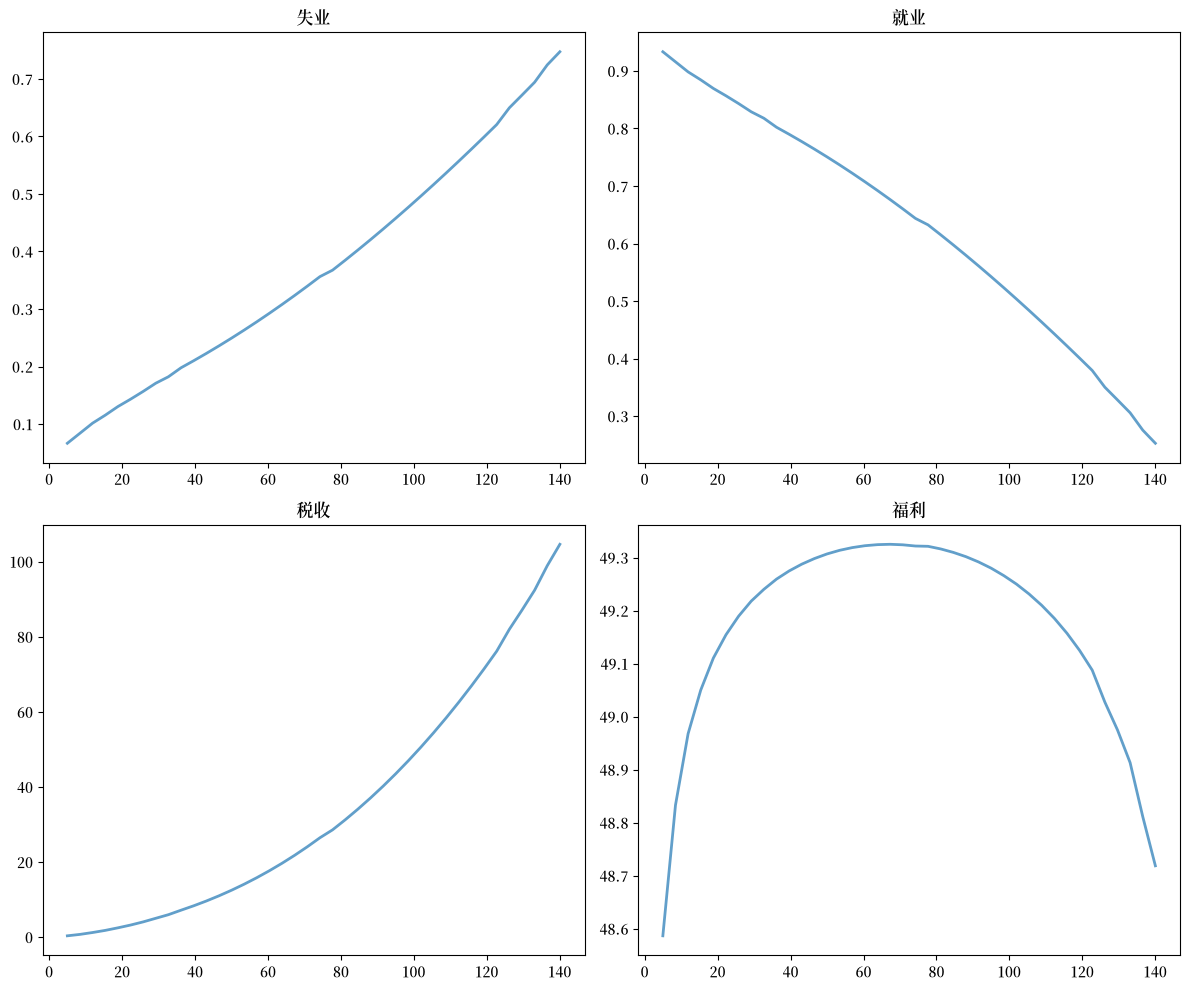

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

plots = [unempl_vec, empl_vec, tax_vec, welfare_vec]
titles = ['失业', '就业', '税收', '福利']

for ax, plot, title in zip(axes.flatten(), plots, titles):
    ax.plot(c_vec, plot, lw=2, alpha=0.7)
    ax.set_title(title)

plt.tight_layout()
plt.show()

随着失业补助的增加，福利先增加后减少。

使稳态福利最大化的水平大约为 62。

## 练习

```{exercise}
:label: endogenous_lake_ex1

使稳态福利最大化的失业补偿水平 $c$ 如何随工作分离率 $\alpha$ 变化？

对于从 0.01 到 0.04 的一系列分离率 $\alpha$，计算并绘制最优 $c$（使福利最大化的值）。

对于每个 $\alpha$ 值，通过在 $c$ 值范围内计算福利并选择最大值来找到最优 $c$。
```

```{solution-start} endogenous_lake_ex1
:class: dropdown
```

这是一个解法：

findfont: Failed to find font weight normal, now using 600.


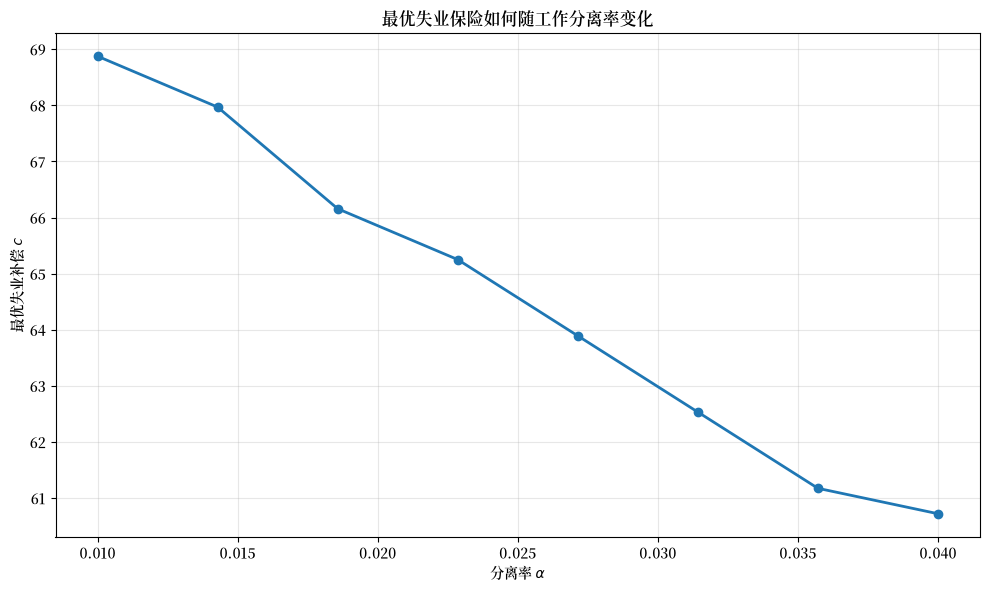

In [16]:
# 要探索的分离率范围（更宽的范围，更少的点）
α_values = jnp.linspace(0.01, 0.04, 8)

# 我们将为每个 α 存储最优 c
optimal_c_values = []

# 使用更精细的 c 值网格以获得更好的分辨率
c_vec_fine = jnp.linspace(5, 140, 150)

for α_val in α_values:
    # 使用该 α 创建经济体参数
    params_α = create_economy(α=α_val)

    # 创建工资分布
    w_vec_α, p_vec_α = create_wage_distribution(
        params_α.max_wage, params_α.wage_grid_size, params_α.log_wage_mean
    )

    # 为每个 c 值计算福利
    welfare_values = []
    for c in c_vec_fine:
        t = find_balanced_budget_tax(c, params_α, w_vec_α, p_vec_α)
        e_rate, u_rate, welfare = compute_steady_state_quantities(
            c, t, params_α, w_vec_α, p_vec_α
        )
        welfare_values.append(welfare)

    # 福利函数在其最大值附近非常平坦。
    # 由于数值噪声，在单个点上使用 argmax 可能不稳定。
    # 相反，我们找到所有在最大福利 99.9% 范围内的 c 值，并
    # 计算它们的加权平均（质心）。这给出了最优失业补偿水平
    # 的更稳定估计。
    welfare_array = jnp.array(welfare_values)
    max_welfare = jnp.max(welfare_array)
    threshold = 0.999 * max_welfare
    near_optimal_mask = welfare_array >= threshold

    # 计算近最优区域内 c 值的加权平均
    optimal_c = jnp.sum(c_vec_fine * near_optimal_mask * welfare_array) / \
                jnp.sum(near_optimal_mask * welfare_array)
    optimal_c_values.append(optimal_c)

# 绘制这种关系
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(α_values, optimal_c_values, lw=2, marker='o')
ax.set_xlabel(r'分离率 $\alpha$')
ax.set_ylabel('最优失业补偿 $c$')
ax.set_title('最优失业保险如何随工作分离率变化')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

我们看到，随着分离率增加（工人更频繁地失去工作），使福利最大化的失业补偿水平会下降。

这是因为更高的分离率增加了稳态失业率，从而提高了为失业补助提供资金所需的税收负担。最优政策在保险与扭曲性税收之间取得平衡。


```{solution-end}
```